In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

plt.style.use("ggplot")
plt.rcParams["font.family"] = "Tahoma"  # ensure Thai glyphs render

data_path = "../data/plate_upper_synth/labels.csv"
df = pd.read_csv(data_path)

print(f"rows: {len(df):,}")
df.head()

rows: 150,000


,filename,label,source,transactionDate,plate,province_code,province_description,brand_description,colors_code,colors_description,vehicleClass
0,synth_upper_000000.jpg,บษ2565,synthetic_upper,NaN,บษ2565,NaN,NaN,NaN,NaN,NaN,1.0
1,synth_upper_000001.jpg,ทหภ3818,synthetic_upper,NaN,ทหภ3818,NaN,NaN,NaN,NaN,NaN,1.0
2,synth_upper_000002.jpg,ถฐ2888,synthetic_upper,NaN,ถฐ2888,NaN,NaN,NaN,NaN,NaN,1.0
3,synth_upper_000003.jpg,ฆญ1378,synthetic_upper,NaN,ฆญ1378,NaN,NaN,NaN,NaN,NaN,1.0
4,synth_upper_000004.jpg,ญฑ5693,synthetic_upper,NaN,ญฑ5693,NaN,NaN,NaN,NaN,NaN,1.0


,count
ก,7241
ข,7179
ค,7090
ฆ,7232
ง,7074
จ,7200
ฉ,7091
ช,7073
ซ,7097
ฌ,7196


,count
0,58633
1,58432
2,58374
3,58722
4,58582
5,58179
6,58428
7,58721
8,58598
9,58262


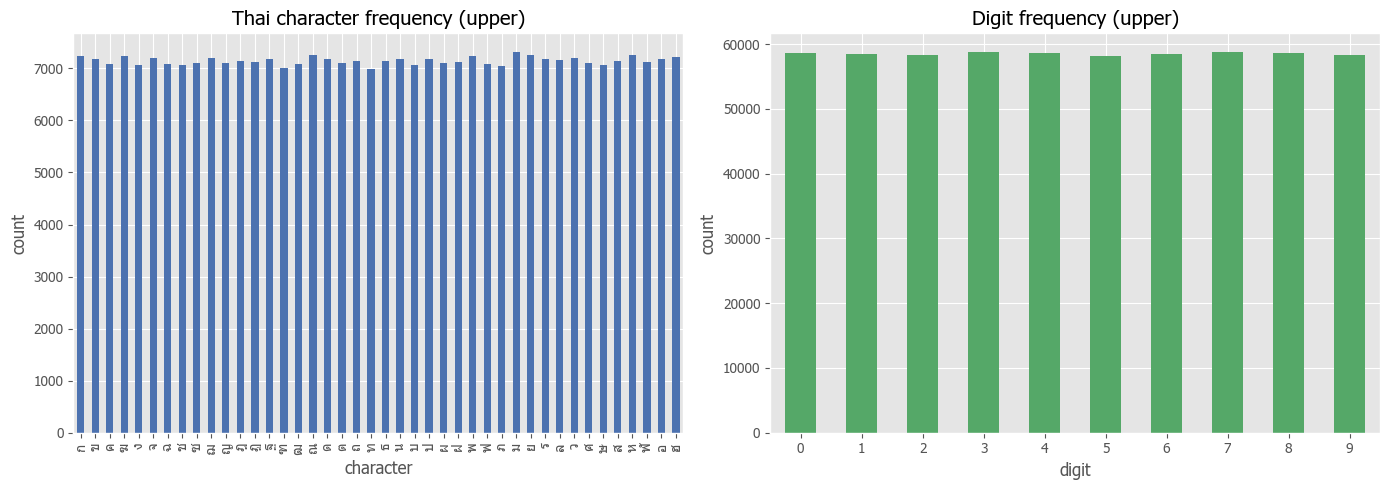

Saved: D:\CodingD\ALPR\debugging\exports\upper_thai_character_frequency.csv
Saved: D:\CodingD\ALPR\debugging\exports\upper_digit_frequency.csv


In [5]:
# Count Thai letters (upper line) and digits across all plates
from pathlib import Path

plates = (
    df["label"]
    .fillna("")
    .astype(str)
    .str.replace("ไม่พบข้อมูล", "", regex=False)
)

thai_letters = [
    "ก","ข","ค","ฆ","ง","จ","ฉ","ช","ซ","ฌ","ญ","ฎ","ฏ","ฐ","ฑ","ฒ","ณ","ด","ต","ถ","ท","ธ","น","บ","ป","ผ","ฝ","พ","ฟ","ภ","ม","ย","ร","ล","ว","ศ","ษ","ส","ห","ฬ","อ","ฮ",
]
digit_labels = list("0123456789")

thai_pattern = re.compile(r"[\u0E00-\u0E7F]")
digit_pattern = re.compile(r"\d")

thai_counter = Counter()
digit_counter = Counter()

for plate in plates:
    thai_counter.update(thai_pattern.findall(plate))
    digit_counter.update(digit_pattern.findall(plate))

thai_series = (
    pd.Series(thai_counter, dtype=int)
    .reindex(thai_letters)
    .fillna(0)
    .astype(int)
    .sort_index()
)
digit_series = (
    pd.Series(digit_counter, dtype=int)
    .reindex(digit_labels)
    .fillna(0)
    .astype(int)
)

thai_df = thai_series.to_frame(name="count")
digit_df = digit_series.to_frame(name="count")

display(thai_df)
display(digit_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
thai_series.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Thai character frequency (upper)")
axes[0].set_xlabel("character")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=90)

digit_series.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Digit frequency (upper)")
axes[1].set_xlabel("digit")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

# Export CSV
export_dir = Path("exports")
export_dir.mkdir(parents=True, exist_ok=True)

thai_csv = export_dir / "upper_thai_character_frequency.csv"
digit_csv = export_dir / "upper_digit_frequency.csv"

thai_df.to_csv(thai_csv, encoding="utf-8-sig")
digit_df.to_csv(digit_csv, encoding="utf-8-sig")

print(f"Saved: {thai_csv.resolve()}")
print(f"Saved: {digit_csv.resolve()}")

In [ ]:
# Province distribution (if available)
full_provinces = [
    "กรุงเทพมหานคร","กระบี่","กาญจนบุรี","กาฬสินธุ์","กำแพงเพชร","ขอนแก่น","จันทบุรี","ฉะเชิงเทรา","ชลบุรี","ชัยนาท","ชัยภูมิ","ชุมพร","เชียงราย","เชียงใหม่","ตรัง","ตราด","ตาก","นครนายก","นครปฐม","นครพนม","นครราชสีมา","นครศรีธรรมราช","นครสวรรค์","นนทบุรี","นราธิวาส","น่าน","บึงกาฬ","บุรีรัมย์","ปทุมธานี","ประจวบคีรีขันธ์","ปราจีนบุรี","ปัตตานี","พระนครศรีอยุธยา","พังงา","พัทลุง","พิจิตร","พิษณุโลก","เพชรบุรี","เพชรบูรณ์","แพร่","ภูเก็ต","มหาสารคาม","มุกดาหาร","แม่ฮ่องสอน","ยโสธร","ยะลา","ร้อยเอ็ด","ระนอง","ระยอง","ราชบุรี","ลพบุรี","ลำปาง","ลำพูน","เลย","ศรีสะเกษ","สกลนคร","สงขลา","สตูล","สมุทรปราการ","สมุทรสงคราม","สมุทรสาคร","สระแก้ว","สระบุรี","สิงห์บุรี","สุโขทัย","สุพรรณบุรี","สุราษฎร์ธานี","สุรินทร์","หนองคาย","หนองบัวลำภู","อ่างทอง","อำนาจเจริญ","อุดรธานี","อุตรดิตถ์","อุทัยธานี","อุบลราชธานี","เบตง",
]

province_col = "province_description" if "province_description" in df.columns else "label"
province_counts_raw = (
    df[province_col]
    .replace("ไม่พบข้อมูล", pd.NA)
    .dropna()
    .astype(str)
    .str.strip()
)

province_counts = (
    province_counts_raw.value_counts()
    .reindex(full_provinces)
    .fillna(0)
    .astype(int)
)

province_df = province_counts.to_frame(name="count")
display(province_df)

plt.figure(figsize=(16, 5))
province_counts.plot(kind="bar", color="#C44E52")
plt.title("Province distribution (upper)")
plt.xlabel("province")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Export CSV
export_dir = Path("exports")
export_dir.mkdir(parents=True, exist_ok=True)

province_csv = export_dir / "upper_province_distribution.csv"
province_df.to_csv(province_csv, encoding="utf-8-sig")
print(f"Saved: {province_csv.resolve()}")